# InvObs DA Assimilation-Window Sweep (PyTorch)

Branch of `PyTorch_InvObs_DA.ipynb` for testing the simple no-background DA loss with cached Lorenz96 inverse-observation CNN weights.

This notebook keeps the parent setup through model recreation/loading, then sweeps assimilation windows `T = [1, 5, 10, 20, 50, 100]` across baseline init, inverse init, observation-space optimization, and hybrid physics-to-observation optimization. The extra logging records L-BFGS closure loss values, gradient norms, nonfinite failures, and forecast error so long windows can expose exploding gradients.

In [ ]:
# Colab setup
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

import sys, subprocess
def pip(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])

# torchdiffeq is optional Ã¢â‚¬â€ we use a hand-written RK4 below. Uncomment if you want adaptive solvers.
# pip('torchdiffeq')

In [2]:
import math
from functools import partial
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_default_dtype(torch.float32)
torch.manual_seed(0)
np.random.seed(0)
print(f'device={device}, torch={torch.__version__}')

device=cpu, torch=2.10.0+cpu


### Disk cache

The CNN is not retrained here. The checkpoint `l96_inverter_sigma0.0_n32000_ep500.pt` must already exist in `CACHE_DIR`. In Colab this defaults to `/content/drive/MyDrive/invobs_cache`; locally you can point `INVOBS_CACHE_DIR` at another cache directory.

In [3]:
import os

FORCE_RETRAIN = False
CACHE_DIR = os.environ.get('INVOBS_CACHE_DIR', '/content/drive/MyDrive/invobs_cache')

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
os.makedirs(CACHE_DIR, exist_ok=True)


def cache_path(name):
    return os.path.join(CACHE_DIR, name)


def save_cache(obj, name):
    torch.save(obj, cache_path(name))
    print(f'  [cache] wrote {name}')


def load_cache(name):
    p = cache_path(name)
    if FORCE_RETRAIN or not os.path.exists(p):
        return None
    print(f'  [cache] loaded {name}')
    try:
        return torch.load(p, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(p, map_location=device)


print(f'Cache dir: {CACHE_DIR}')
print(f'Existing cache files: {sorted(os.listdir(CACHE_DIR)) if os.path.isdir(CACHE_DIR) else []}')

Mounted at /content/drive
Cache dir: /content/drive/MyDrive/invobs_cache
Existing cache files: ['.ipynb_checkpoints', 'l96_corr.pt', 'l96_expA_4combo_N100_T10.pt', 'l96_inverter_sigma0.0_n32000_ep500.pt', 'l96_inverter_sigma0.1_n32000_ep500.pt', 'l96_inverter_sigma0.5_n32000_ep500.pt', 'l96_inverter_sigma1.0_n32000_ep500.pt', 'l96_inverter_sigma10.0_n32000_ep500.pt', 'l96_inverter_sigma5.0_n32000_ep500.pt', 'l96_noise_results_4combo_n32000_ep500.pt', 'l96_train_data_n32000_T20_warmup1000_sigma0.0.pt', 'l96_train_data_n32000_T20_warmup1000_sigma0.1.pt', 'l96_train_data_n32000_T20_warmup1000_sigma0.5.pt', 'l96_train_data_n32000_T20_warmup1000_sigma1.0.pt', 'l96_train_data_n32000_T20_warmup1000_sigma10.0.pt', 'l96_train_data_n32000_T20_warmup1000_sigma5.0.pt', 'l96_window_sweep_v1_ckptl96_inverter_sigma0.0_n32000_ep500_T100_N100_forecast40_sigma0.0_warmup500_seed1806_obs500_hybrid100-400.pt', 'l96_window_sweep_v1_ckptl96_inverter_sigma0.0_n32000_ep500_T10_N100_forecast40_sigma0.0_warmup50

---
## 1. Lorenz96

$\dot x_k = -x_{k-1}(x_{k-2} - x_{k+1}) - x_k + F$ with periodic BCs. Observation operator: subsample every `observe_every` grid points.

In [4]:
def rk4_step(rhs, x, dt):
    k1 = rhs(x)
    k2 = rhs(x + 0.5 * dt * k1)
    k3 = rhs(x + 0.5 * dt * k2)
    k4 = rhs(x + dt * k3)
    return x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


class Lorenz96:
    def __init__(self, grid_size=40, F=8.0, dt=0.01, observe_every=4, n_inner=10):
        # n_inner internal RK4 steps per "outer" step of size dt*n_inner.
        self.grid_size = grid_size
        self.F = F
        self.dt = dt
        self.n_inner = n_inner
        self.outer_dt = dt * n_inner
        self.observe_every = observe_every

    def rhs(self, x):
        xp1 = torch.roll(x, -1, dims=-1)
        xm1 = torch.roll(x,  1, dims=-1)
        xm2 = torch.roll(x,  2, dims=-1)
        return (xp1 - xm2) * xm1 - x + self.F

    def step(self, x):
        for _ in range(self.n_inner):
            x = rk4_step(self.rhs, x, self.dt)
        return x

    def integrate(self, x0, n_steps, start_with_input=True):
        traj = [x0] if start_with_input else []
        x = x0
        n = n_steps if start_with_input else n_steps
        for t in range(n_steps - (1 if start_with_input else 0)):
            x = self.step(x)
            traj.append(x)
        return torch.stack(traj, dim=0)  # (T, ..., grid_size)

    def warmup(self, x0, total_inner_steps):
        x = x0
        for _ in range(total_inner_steps):
            x = rk4_step(self.rhs, x, self.dt)
        return x

    def observe(self, x):
        return x[..., ::self.observe_every]


L96 = Lorenz96(grid_size=40, dt=0.01, n_inner=10, observe_every=4)  # outer_dt = 0.1

### Data generation and spatial correlation

`generate_data` returns `(X0, X_true, Y)` where `Y = H(X_true) + noise`. Also computes a long trajectory for estimating the spatial correlation matrix `C` used to precondition the optimizer.

In [5]:
def generate_data(dyn_sys, n_samples, n_time_steps, n_warmup, obs_noise_std=0.0, seed=0):
    g = torch.Generator(device=device).manual_seed(seed)
    X0_cold = torch.randn(n_samples, dyn_sys.grid_size, device=device, generator=g) * 0.5
    # Batched warmup: all N samples spun up simultaneously as (N, grid) Ã¢â‚¬â€ no Python loop.
    X0 = dyn_sys.warmup(X0_cold, n_warmup)                          # (N, grid)
    # Batched integrate: returns (T, N, grid); permute to (N, T, grid).
    X = dyn_sys.integrate(X0, n_time_steps).permute(1, 0, 2)        # (N, T, grid)
    Y_clean = dyn_sys.observe(X)                                     # (N, T, obs_grid)
    noise = torch.empty_like(Y_clean).normal_(generator=g) * obs_noise_std
    Y = Y_clean + noise
    return X0, X, Y, Y_clean


def estimate_correlation(dyn_sys, n_samples=2000, n_warmup=1000, seed=1):
    g = torch.Generator(device=device).manual_seed(seed)
    X0 = torch.randn(n_samples, dyn_sys.grid_size, device=device, generator=g) * 0.5
    # Batched warmup.
    X = dyn_sys.warmup(X0, n_warmup)                                 # (N, grid)
    X = X - X.mean(dim=0, keepdim=True)
    C = (X.T @ X) / (X.shape[0] - 1)
    eigvals, eigvecs = torch.linalg.eigh(C)
    eigvals = torch.clamp(eigvals, min=1e-8)
    C_sqrt     = eigvecs @ torch.diag(eigvals.sqrt())  @ eigvecs.T
    C_inv_sqrt = eigvecs @ torch.diag(eigvals.rsqrt()) @ eigvecs.T
    C_inv      = eigvecs @ torch.diag(1.0 / eigvals)   @ eigvecs.T
    return dict(C=C, C_sqrt=C_sqrt, C_inv_sqrt=C_inv_sqrt, C_inv=C_inv)


corr = load_cache('l96_corr.pt')
if corr is None:
    corr = estimate_correlation(L96, n_samples=1000, n_warmup=500)
    save_cache(corr, 'l96_corr.pt')
print('C shape:', corr['C'].shape, 'cond=', torch.linalg.cond(corr['C']).item())

  [cache] loaded l96_corr.pt
C shape: torch.Size([40, 40]) cond= 8.721685409545898


### Inverse observation operator $H^{-1}_\theta$

Maps an *observation sequence* $Y \in \mathbb{R}^{T \times n_{obs}}$ back to full physical space $X \in \mathbb{R}^{T \times n_{grid}}$. CNN with **periodic** padding in the grid dimension and **zero** padding in time (matches the paper's `PeriodicSpaceConv`).

In [6]:
class PeriodicSpaceConv2d(nn.Module):
    """Conv2d over (time, space). Space gets periodic padding, time gets zero padding."""
    def __init__(self, in_ch, out_ch, k_t=3, k_x=3):
        super().__init__()
        self.k_t = k_t
        self.k_x = k_x
        # Inner conv has 'valid' behavior; we pad manually.
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=(k_t, k_x), padding=0)

    def forward(self, x):  # x: (B, C, T, X)
        pt = (self.k_t - 1) // 2
        px = (self.k_x - 1) // 2
        x = F.pad(x, (px, px, 0, 0), mode='circular')  # wrap space
        x = F.pad(x, (0, 0, pt, pt), mode='constant')  # zero time
        return self.conv(x)


class InverseObsLorenz96(nn.Module):
    def __init__(self, obs_grid=10, full_grid=40, hidden=32, n_layers=6):
        super().__init__()
        self.obs_grid = obs_grid
        self.full_grid = full_grid
        self.in_proj = PeriodicSpaceConv2d(1, hidden, 3, 3)
        self.blocks = nn.ModuleList(
            [PeriodicSpaceConv2d(hidden, hidden, 3, 3) for _ in range(n_layers)]
        )
        self.out_proj = PeriodicSpaceConv2d(hidden, 1, 3, 3)

    def forward(self, y):  # y: (B, T, obs_grid) -> (B, T, full_grid)
        B, T, _ = y.shape
        x = y.unsqueeze(1)  # (B, 1, T, obs_grid)
        # Spatial upsample with periodic-aware linear interp:
        x = F.interpolate(x, size=(T, self.full_grid), mode='bilinear', align_corners=False)
        x = F.gelu(self.in_proj(x))
        for blk in self.blocks:
            x = x + F.gelu(blk(x))
        x = self.out_proj(x)
        return x.squeeze(1)

### Load cached inverse observation operator

This branch deliberately fails fast if the cached CNN weights are absent, because the window sweep is meant to test assimilation behavior with the current trained model rather than retraining a new one.

  [cache] loaded l96_inverter_sigma0.0_n32000_ep500.pt
Loaded cached inverse-observation CNN: l96_inverter_sigma0.0_n32000_ep500.pt


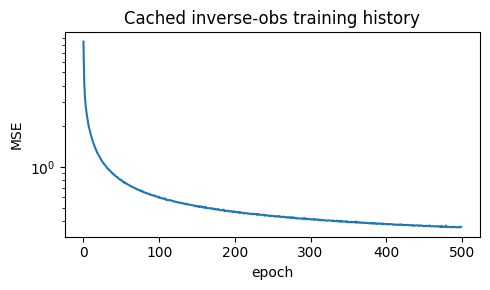

In [7]:
INVERTER_CKPT = 'l96_inverter_sigma0.0_n32000_ep500.pt'

inverter = InverseObsLorenz96(obs_grid=10, full_grid=40, hidden=32, n_layers=6).to(device)
ckpt = load_cache(INVERTER_CKPT)
if ckpt is None:
    raise FileNotFoundError(
        f'Missing cached CNN weights: {cache_path(INVERTER_CKPT)}\n'
        'Run the parent notebook training cell once, or set INVOBS_CACHE_DIR to a cache '
        'directory that already contains this checkpoint.'
    )

inverter.load_state_dict(ckpt['state_dict'])
inverter.eval()
hist = ckpt.get('hist')
print(f'Loaded cached inverse-observation CNN: {INVERTER_CKPT}')

if hist is not None:
    plt.figure(figsize=(5, 3))
    plt.plot(hist)
    plt.yscale('log')
    plt.xlabel('epoch')
    plt.ylabel('MSE')
    plt.title('Cached inverse-obs training history')
    plt.tight_layout()
    plt.show()

### Simple-loss DA with gradient diagnostics

The loss is the parent notebook's simple objective: either observation-space MSE or physics-space MSE against the cached inverse observation trajectory, with no background term. The optimizer is still PyTorch L-BFGS; the only change is diagnostic bookkeeping around each closure.

In [8]:
def decorrelate(x, C_inv_sqrt):
    # x: (..., grid) -> z: (..., grid)
    return x @ C_inv_sqrt


def correlate(z, C_sqrt):
    return z @ C_sqrt


def da_loss(Z0, Y, dyn_sys, C_sqrt, T, mode, inverter=None):
    """Simple no-background DA loss in decorrelated coordinates.
    Z0: (N, grid) decorrelated initial states.
    Y:  (N, T, obs_grid) observations.
    """
    X0 = correlate(Z0, C_sqrt)
    traj = dyn_sys.integrate(X0, T)
    if mode == 'obs':
        pred = dyn_sys.observe(traj)
        target = Y.transpose(0, 1)
    elif mode == 'physics':
        assert inverter is not None
        with torch.no_grad():
            inv = inverter(Y)
        pred = traj
        target = inv.transpose(0, 1)
    else:
        raise ValueError(mode)
    return ((pred - target) ** 2).mean()


def lbfgs_minimize(loss_fn, z0_init, max_iter=200, history_size=20, lr=1.0):
    """Same L-BFGS optimizer as the parent notebook, with closure diagnostics added."""
    z = z0_init.clone().detach().requires_grad_(True)
    opt = torch.optim.LBFGS(
        [z], max_iter=max_iter, history_size=history_size,
        tolerance_grad=1e-12, tolerance_change=1e-12,
        line_search_fn='strong_wolfe', lr=lr,
    )
    diag = {
        'loss': [],
        'grad_norm': [],
        'grad_abs_max': [],
        'status': 'ok',
        'exception': None,
    }

    def closure():
        opt.zero_grad()
        loss = loss_fn(z)
        if not torch.isfinite(loss):
            raise FloatingPointError(f'nonfinite loss: {loss.item()}')
        loss.backward()
        grad = z.grad.detach()
        grad_norm = torch.linalg.vector_norm(grad).item()
        grad_abs_max = grad.abs().max().item()
        diag['loss'].append(loss.item())
        diag['grad_norm'].append(grad_norm)
        diag['grad_abs_max'].append(grad_abs_max)
        if not np.isfinite(grad_norm) or not np.isfinite(grad_abs_max):
            raise FloatingPointError(f'nonfinite gradient: norm={grad_norm}, max={grad_abs_max}')
        return loss

    try:
        opt.step(closure)
    except Exception as exc:
        diag['status'] = 'failed'
        diag['exception'] = repr(exc)
    return z.detach(), diag

In [9]:
def run_da(dyn_sys, inverter, corr, X0_init, Y, T, physics_steps=0, obs_steps=500):
    """Batched DA with the simple loss. Returns recovered x0 plus per-stage diagnostics."""
    C_sqrt, C_inv_sqrt = corr['C_sqrt'], corr['C_inv_sqrt']
    Z0 = decorrelate(X0_init, C_inv_sqrt)
    stage_diags = []

    if physics_steps > 0:
        loss_p = partial(
            da_loss, Y=Y, dyn_sys=dyn_sys, C_sqrt=C_sqrt, T=T,
            mode='physics', inverter=inverter,
        )
        Z0, diag_p = lbfgs_minimize(loss_p, Z0, max_iter=physics_steps)
        diag_p['stage'] = 'physics'
        stage_diags.append(diag_p)
        if diag_p['status'] != 'ok':
            return correlate(Z0, C_sqrt), stage_diags

    if obs_steps > 0:
        loss_o = partial(da_loss, Y=Y, dyn_sys=dyn_sys, C_sqrt=C_sqrt, T=T, mode='obs')
        Z0, diag_o = lbfgs_minimize(loss_o, Z0, max_iter=obs_steps)
        diag_o['stage'] = 'obs'
        stage_diags.append(diag_o)

    return correlate(Z0, C_sqrt), stage_diags


def baseline_init_l96(dyn_sys, Y):
    """Nearest-neighbor upsample from t=0 observations."""
    if Y.ndim == 3:
        return Y[:, 0].repeat_interleave(dyn_sys.observe_every, dim=-1)
    return Y[0].repeat_interleave(dyn_sys.observe_every)


def invobs_init_l96(inverter, Y):
    with torch.no_grad():
        return inverter(Y).detach()[:, 0]

---
## Assimilation-window sweep

In [10]:
import time

USE_WINDOW_CACHE = True
SAVE_WINDOW_CACHE = True

ASSIM_WINDOWS = [1, 2, 3, 4, 5, 10, 20, 50, 100]
N_SWEEP = 100
T_FORECAST = 40
OBS_NOISE_STD = 0.0
N_WARMUP = 500
BASE_SEED = 1706

OBS_STEPS = 500
HYBRID_PHYSICS_STEPS = 100
HYBRID_OBS_STEPS = 400
GRAD_EXPLODE_THRESHOLD = 1e8

COMBOS = {
    'baseline init + observation opt': dict(init='baseline', p_steps=0, o_steps=OBS_STEPS),
    'inverse init + observation opt':  dict(init='invobs',   p_steps=0, o_steps=OBS_STEPS),
    'baseline init + hybrid opt':      dict(init='baseline', p_steps=HYBRID_PHYSICS_STEPS, o_steps=HYBRID_OBS_STEPS),
    'inverse init + hybrid opt':       dict(init='invobs',   p_steps=HYBRID_PHYSICS_STEPS, o_steps=HYBRID_OBS_STEPS),
}

WINDOW_CACHE_VERSION = 1


def window_cache_key(T_assim):
    return (
        f'l96_window_sweep_v{WINDOW_CACHE_VERSION}_'
        f'ckpt{os.path.splitext(INVERTER_CKPT)[0]}_'
        f'T{T_assim}_N{N_SWEEP}_forecast{T_FORECAST}_'
        f'sigma{OBS_NOISE_STD}_warmup{N_WARMUP}_seed{BASE_SEED + T_assim}_'
        f'obs{OBS_STEPS}_hybrid{HYBRID_PHYSICS_STEPS}-{HYBRID_OBS_STEPS}.pt'
    )

print('windows:', ASSIM_WINDOWS)
print('samples per window:', N_SWEEP)
print('forecast length:', T_FORECAST)
print('gradient explosion threshold:', GRAD_EXPLODE_THRESHOLD)
print('window cache example:', window_cache_key(ASSIM_WINDOWS[0]))
print('use window cache:', USE_WINDOW_CACHE)

windows: [1, 2, 3, 4, 5, 10, 20, 50, 100]
samples per window: 100
forecast length: 40
gradient explosion threshold: 100000000.0
window cache example: l96_window_sweep_v1_ckptl96_inverter_sigma0.0_n32000_ep500_T1_N100_forecast40_sigma0.0_warmup500_seed1707_obs500_hybrid100-400.pt
use window cache: True


In [11]:
def combine_stage_history(stage_diags, key):
    values = []
    for diag in stage_diags:
        values.extend(diag.get(key, []))
    return values


def max_or_nan(values):
    return float(np.max(values)) if len(values) else float('nan')


def summarize_da_result(name, T_assim, X0_opt, X0_gt, X_truth, stage_diags, elapsed):
    X_pred = L96.integrate(X0_opt.detach(), T_assim + T_FORECAST)
    l1_t = (X_pred - X_truth).abs().mean(dim=-1).mean(dim=-1).detach().cpu().numpy()
    rmse0 = ((X0_opt - X0_gt) ** 2).mean(dim=-1).sqrt().mean().item()
    grad_norm = combine_stage_history(stage_diags, 'grad_norm')
    grad_abs_max = combine_stage_history(stage_diags, 'grad_abs_max')
    status = 'ok' if all(d.get('status') == 'ok' for d in stage_diags) else 'failed'
    exception = '; '.join(str(d.get('exception')) for d in stage_diags if d.get('exception'))
    max_grad_norm = max_or_nan(grad_norm)
    max_grad_abs = max_or_nan(grad_abs_max)
    exploded = (
        status != 'ok'
        or not np.isfinite(max_grad_norm)
        or not np.isfinite(max_grad_abs)
        or max_grad_norm > GRAD_EXPLODE_THRESHOLD
        or max_grad_abs > GRAD_EXPLODE_THRESHOLD
    )
    return {
        'window': T_assim,
        'method': name,
        'status': status,
        'exploded': exploded,
        'x0_rmse': rmse0,
        'assim_l1': float(np.mean(l1_t[:T_assim])),
        'forecast_l1': float(np.mean(l1_t[T_assim:])),
        'final_l1': float(l1_t[-1]),
        'max_grad_norm': max_grad_norm,
        'max_grad_abs': max_grad_abs,
        'n_closures': len(grad_norm),
        'elapsed_s': elapsed,
        'exception': exception,
        'l1_t': l1_t,
        'stage_diags': stage_diags,
        'x0_opt': X0_opt.detach().cpu(),
    }


def print_summary_row(row):
    flag = 'EXPLODED' if row['exploded'] else 'ok'
    print(
        f"T={row['window']:3d} | {row['method']:<32s} | {flag:<8s} "
        f"x0_rmse={row['x0_rmse']:.4f} forecast_l1={row['forecast_l1']:.4f} "
        f"max_grad={row['max_grad_norm']:.3e} closures={row['n_closures']:4d} "
        f"time={row['elapsed_s']:.1f}s"
    )
    if row['exception']:
        print('    exception:', row['exception'])

In [12]:
sweep_results = []
truth_by_window = {}
sweep_metadata = {
    'assim_windows': ASSIM_WINDOWS,
    'n_sweep': N_SWEEP,
    't_forecast': T_FORECAST,
    'obs_noise_std': OBS_NOISE_STD,
    'n_warmup': N_WARMUP,
    'base_seed': BASE_SEED,
    'obs_steps': OBS_STEPS,
    'hybrid_physics_steps': HYBRID_PHYSICS_STEPS,
    'hybrid_obs_steps': HYBRID_OBS_STEPS,
    'inverter_ckpt': INVERTER_CKPT,
    'window_cache_version': WINDOW_CACHE_VERSION,
}

for T_assim in ASSIM_WINDOWS:
    cache_key = window_cache_key(T_assim)
    cached_window = load_cache(cache_key) if USE_WINDOW_CACHE else None

    if cached_window is not None:
        window_rows = cached_window['sweep_results']
        sweep_results.extend(window_rows)
        if 'truth' in cached_window:
            truth_by_window[T_assim] = cached_window['truth']
        print(f'Loaded T={T_assim} window cache with {len(window_rows)} DA runs.')
        continue

    print(f'\n=== assimilation window T={T_assim} ===')
    X0_gt, _, Y, _ = generate_data(
        L96, n_samples=N_SWEEP, n_time_steps=T_assim,
        n_warmup=N_WARMUP, obs_noise_std=OBS_NOISE_STD,
        seed=BASE_SEED + T_assim,
    )
    X_truth = L96.integrate(X0_gt, T_assim + T_FORECAST)
    truth_by_window[T_assim] = {'X0': X0_gt.detach().cpu(), 'Y': Y.detach().cpu()}

    inits = {
        'baseline': baseline_init_l96(L96, Y),
        'invobs': invobs_init_l96(inverter, Y),
    }

    window_rows = []
    for name, cfg in COMBOS.items():
        torch.cuda.empty_cache() if torch.cuda.is_available() else None
        t0 = time.time()
        X0_opt, stage_diags = run_da(
            L96, inverter, corr, inits[cfg['init']], Y, T=T_assim,
            physics_steps=cfg['p_steps'], obs_steps=cfg['o_steps'],
        )
        elapsed = time.time() - t0
        row = summarize_da_result(name, T_assim, X0_opt, X0_gt, X_truth, stage_diags, elapsed)
        window_rows.append(row)
        sweep_results.append(row)
        print_summary_row(row)

    if SAVE_WINDOW_CACHE:
        save_cache({
            'window': T_assim,
            'sweep_results': window_rows,
            'truth': truth_by_window[T_assim],
            'metadata': sweep_metadata,
        }, cache_key)

print(f'\nfinished/loaded {len(sweep_results)} DA runs across {len(ASSIM_WINDOWS)} windows')

  [cache] loaded l96_window_sweep_v1_ckptl96_inverter_sigma0.0_n32000_ep500_T1_N100_forecast40_sigma0.0_warmup500_seed1707_obs500_hybrid100-400.pt
Loaded T=1 window cache with 4 DA runs.
  [cache] loaded l96_window_sweep_v1_ckptl96_inverter_sigma0.0_n32000_ep500_T2_N100_forecast40_sigma0.0_warmup500_seed1708_obs500_hybrid100-400.pt
Loaded T=2 window cache with 4 DA runs.
  [cache] loaded l96_window_sweep_v1_ckptl96_inverter_sigma0.0_n32000_ep500_T3_N100_forecast40_sigma0.0_warmup500_seed1709_obs500_hybrid100-400.pt
Loaded T=3 window cache with 4 DA runs.
  [cache] loaded l96_window_sweep_v1_ckptl96_inverter_sigma0.0_n32000_ep500_T4_N100_forecast40_sigma0.0_warmup500_seed1710_obs500_hybrid100-400.pt
Loaded T=4 window cache with 4 DA runs.
  [cache] loaded l96_window_sweep_v1_ckptl96_inverter_sigma0.0_n32000_ep500_T5_N100_forecast40_sigma0.0_warmup500_seed1711_obs500_hybrid100-400.pt
Loaded T=5 window cache with 4 DA runs.
  [cache] loaded l96_window_sweep_v1_ckptl96_inverter_sigma0.0_n3

### Summary table

In [13]:
summary_rows = [
    {k: row[k] for k in [
        'window', 'method', 'status', 'exploded', 'x0_rmse', 'assim_l1',
        'forecast_l1', 'final_l1', 'max_grad_norm', 'max_grad_abs',
        'n_closures', 'elapsed_s', 'exception',
    ]}
    for row in sweep_results
]

try:
    import pandas as pd
    df_summary = pd.DataFrame(summary_rows)
    display(df_summary)
except Exception:
    for row in summary_rows:
        print(row)

,window,method,status,exploded,x0_rmse,assim_l1,forecast_l1,final_l1,max_grad_norm,max_grad_abs,n_closures,elapsed_s,exception
0,1,baseline init + observation opt,ok,False,4.775115,3.421786,4.082540,4.170492,1.255020e-05,1.072576e-06,6,0.011345,
1,1,inverse init + observation opt,ok,False,3.379911,2.382437,3.653440,3.997292,7.689258e-01,6.762812e-02,12,0.024590,
2,1,baseline init + hybrid opt,ok,False,3.379916,2.382441,3.653413,3.997294,7.689285e-01,6.762834e-02,41,0.147953,
3,1,inverse init + hybrid opt,ok,False,3.379912,2.382438,3.653435,3.997284,7.689266e-01,6.762817e-02,21,0.050664,
4,2,baseline init + observation opt,ok,False,4.615833,3.161357,4.054773,4.219370,3.499988e-01,6.783508e-02,356,5.702530,
5,2,inverse init + observation opt,ok,False,3.149728,2.075106,3.729115,4.167823,2.803652e-01,3.519256e-02,229,3.644772,
6,2,baseline init + hybrid opt,ok,False,3.153992,2.081029,3.746263,4.116574,4.161627e-01,3.417496e-02,353,5.598095,
7,2,inverse init + hybrid opt,ok,False,3.153996,2.081023,3.747592,4.123862,2.575495e-01,3.417511e-02,329,5.154419,
8,3,baseline init + observation opt,ok,False,5.189099,3.435076,3.973246,4.110029,6.383374e-01,8.715709e-02,513,14.545208,
9,3,inverse init + observation opt,ok,False,2.540466,1.497635,3.495821,4.055807,2.247811e-01,4.119556e-02,513,14.582583,


### Forecast and gradient plots

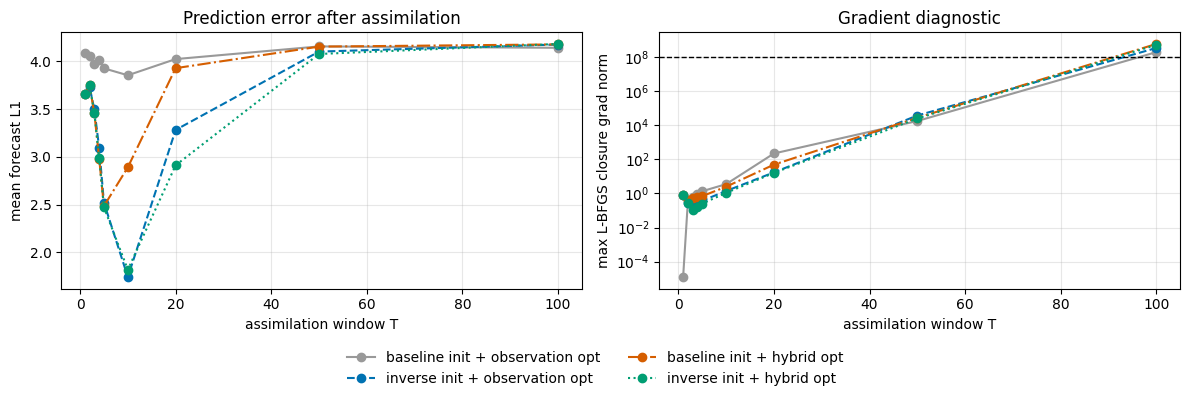

In [14]:
colors = {
    'baseline init + observation opt': '#999999',
    'inverse init + observation opt':  '#0072B2',
    'baseline init + hybrid opt':      '#D55E00',
    'inverse init + hybrid opt':       '#009E73',
}
linestyles = {
    'baseline init + observation opt': '-',
    'inverse init + observation opt': '--',
    'baseline init + hybrid opt': '-.',
    'inverse init + hybrid opt': ':',
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for method in COMBOS:
    rows = [r for r in sweep_results if r['method'] == method]
    xs = [r['window'] for r in rows]
    forecast = [r['forecast_l1'] for r in rows]
    grads = [r['max_grad_norm'] for r in rows]
    axes[0].plot(xs, forecast, marker='o', color=colors[method], linestyle=linestyles[method], label=method)
    axes[1].plot(xs, grads, marker='o', color=colors[method], linestyle=linestyles[method], label=method)

axes[0].set_xlabel('assimilation window T')
axes[0].set_ylabel('mean forecast L1')
axes[0].set_title('Prediction error after assimilation')
axes[0].grid(alpha=0.3)

axes[1].axhline(GRAD_EXPLODE_THRESHOLD, color='k', linestyle='--', linewidth=1, label='explosion threshold')
axes[1].set_yscale('log')
axes[1].set_xlabel('assimilation window T')
axes[1].set_ylabel('max L-BFGS closure grad norm')
axes[1].set_title('Gradient diagnostic')
axes[1].grid(alpha=0.3, which='both')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=2, frameon=False)
fig.suptitle('Window sweep summary', y=1.03)
plt.tight_layout(rect=(0, 0, 1, 0.88))
plt.show()

### Assimilation and forecast rollout plots

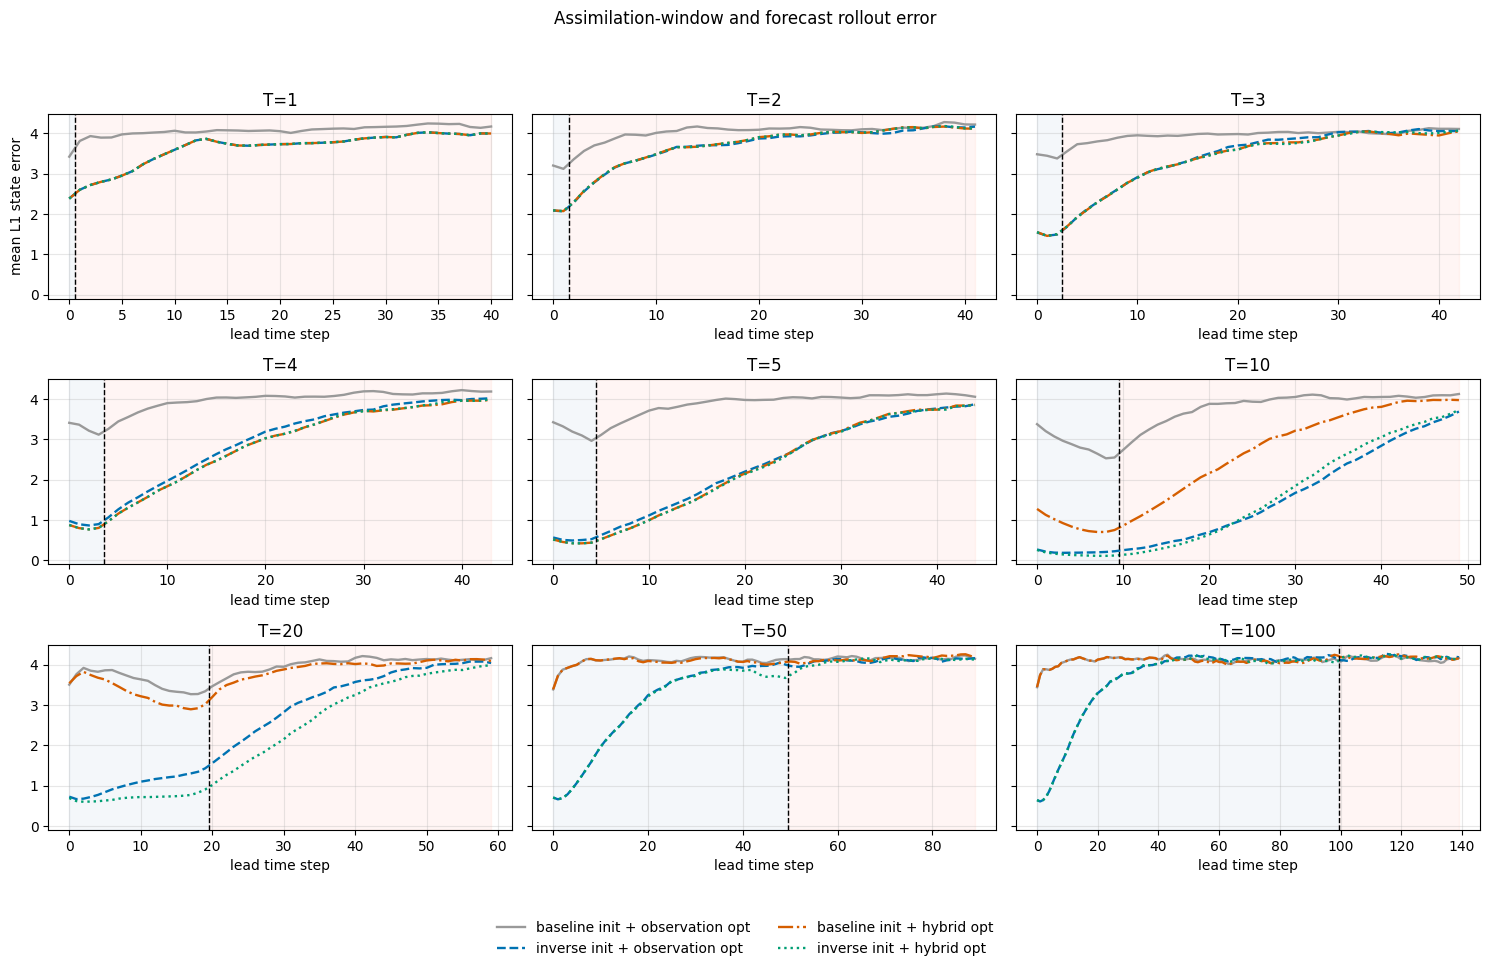

In [15]:
# Mean rollout error over both the assimilation window and forecast period.
ROLLOUT_ERROR_WINDOWS = ASSIM_WINDOWS
ncols = 3
nrows = math.ceil(len(ROLLOUT_ERROR_WINDOWS) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5.6 * ncols, 3.5 * nrows), sharey=False)
axes = np.atleast_1d(axes).ravel()

for ax, T_show in zip(axes, ROLLOUT_ERROR_WINDOWS):
    rows = [r for r in sweep_results if r['window'] == T_show]
    if not rows:
        ax.set_title(f'T={T_show} (missing)')
        ax.axis('off')
        continue

    for row in rows:
        l1_t = np.asarray(row['l1_t'])
        lead = np.arange(len(l1_t))
        ax.plot(
            lead, l1_t,
            color=colors[row['method']], linestyle=linestyles[row['method']],
            lw=1.7, label=row['method'],
        )

    sep = T_show - 0.5
    ax.axvline(sep, color='k', lw=1.0, ls='--')
    ax.axvspan(0, sep, alpha=0.06, color='steelblue')
    ax.axvspan(sep, T_show + T_FORECAST - 1, alpha=0.06, color='tomato')
    ax.set_title(f'T={T_show}')
    ax.set_xlabel('lead time step')
    ax.set_ylabel('mean L1 state error')
    ax.grid(alpha=0.3)

for ax in axes[len(ROLLOUT_ERROR_WINDOWS):]:
    ax.axis('off')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.965), ncol=2, frameon=False)
fig.suptitle('Assimilation-window and forecast rollout error', y=1.01)
plt.tight_layout(rect=(0, 0, 1, 0.88), w_pad=2.0, h_pad=2.0)
plt.show()

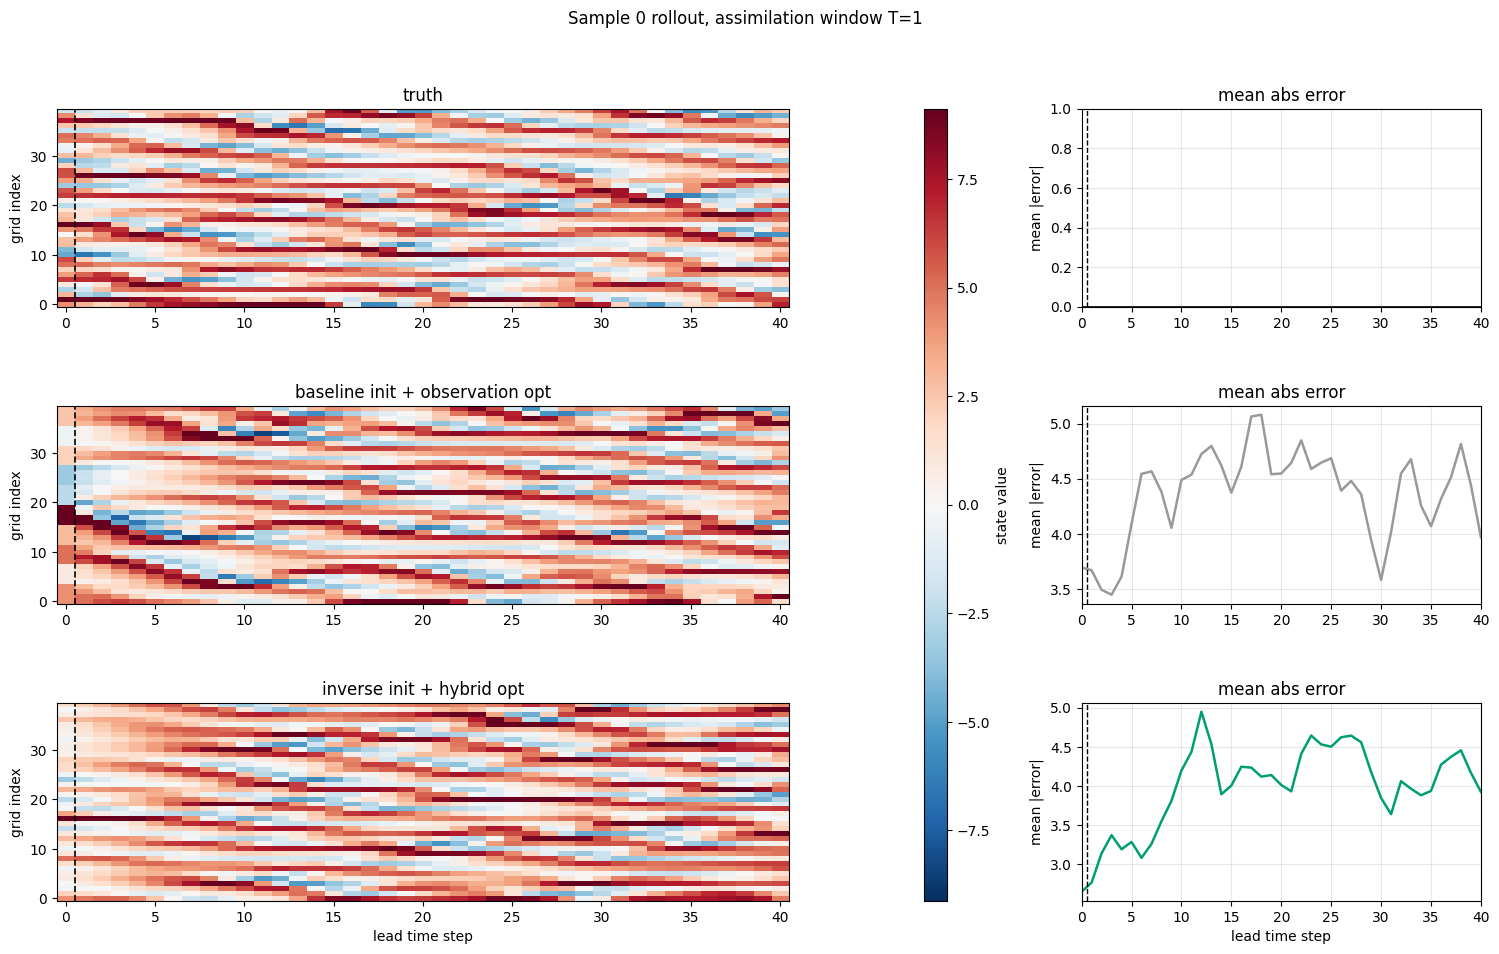

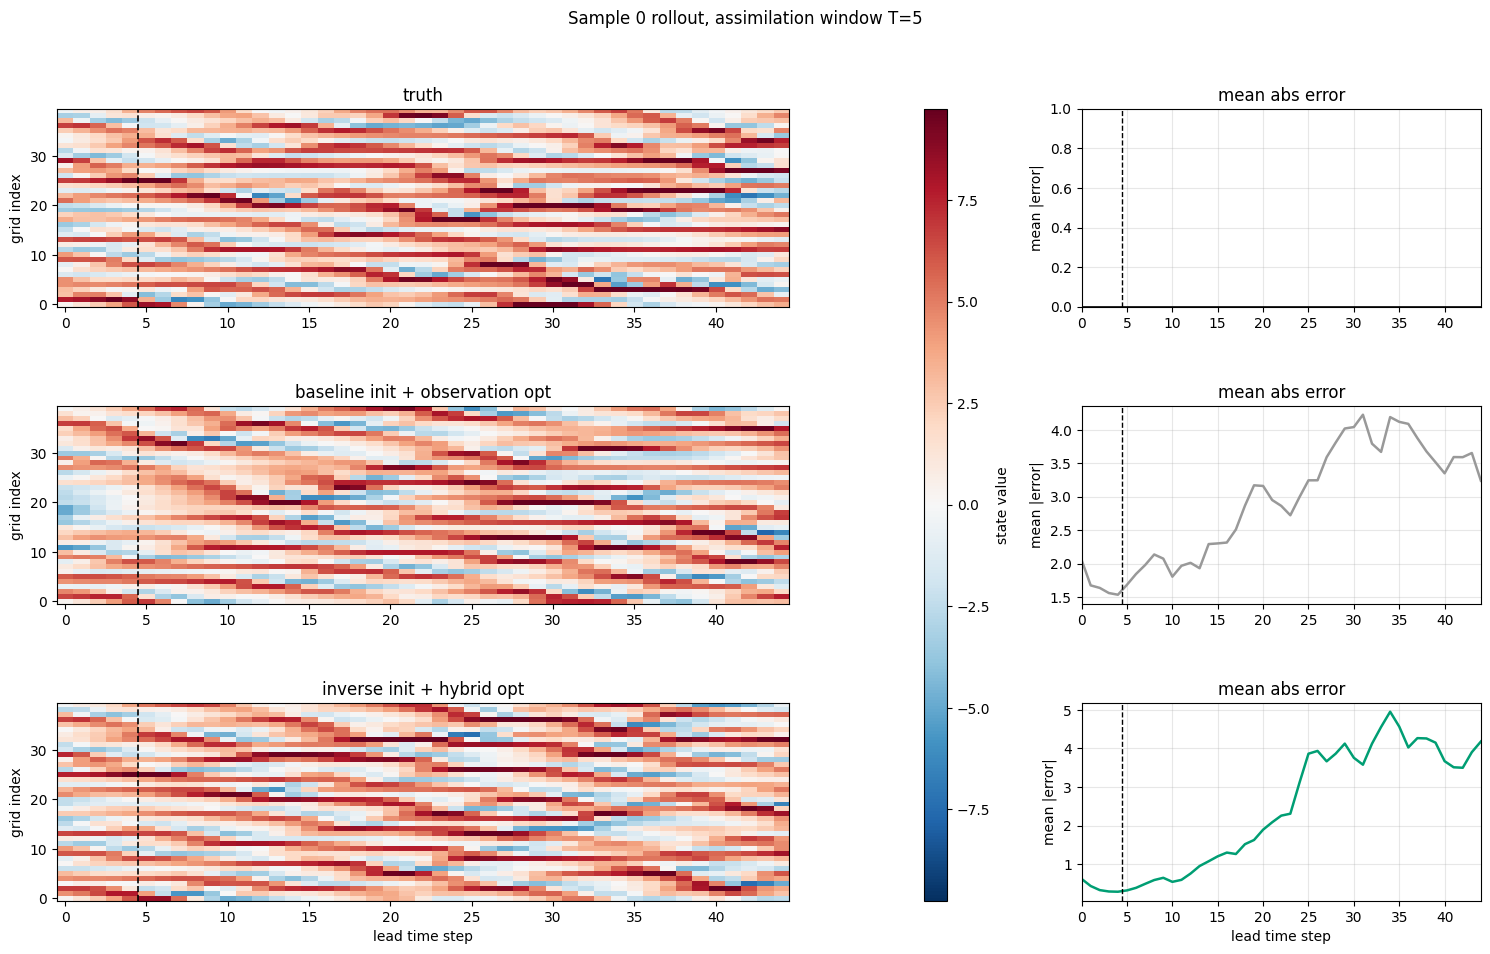

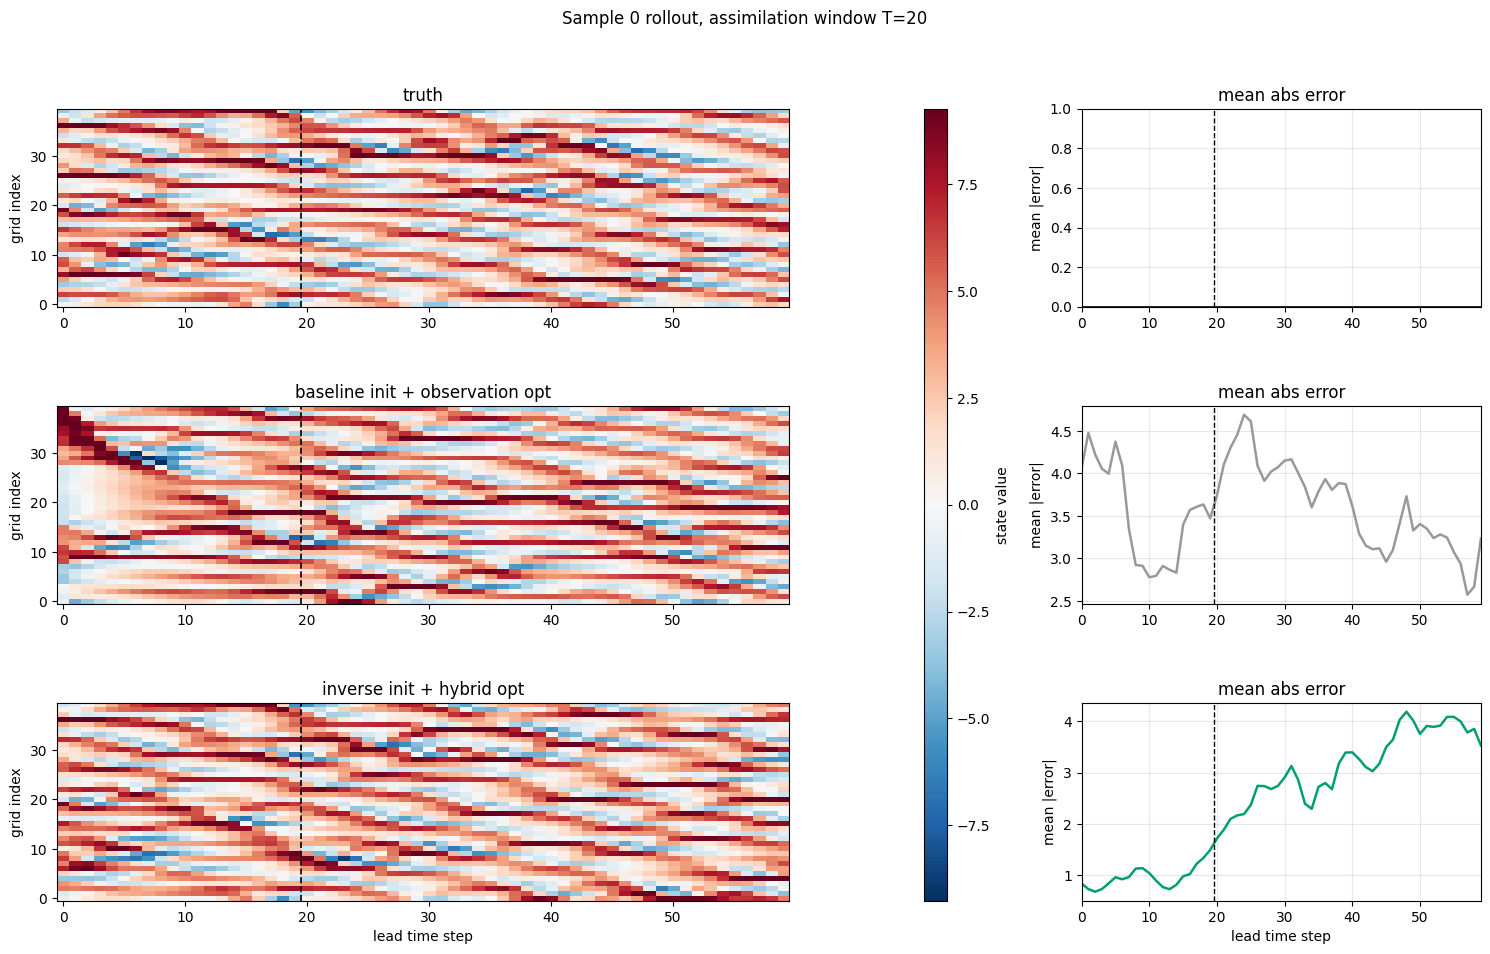

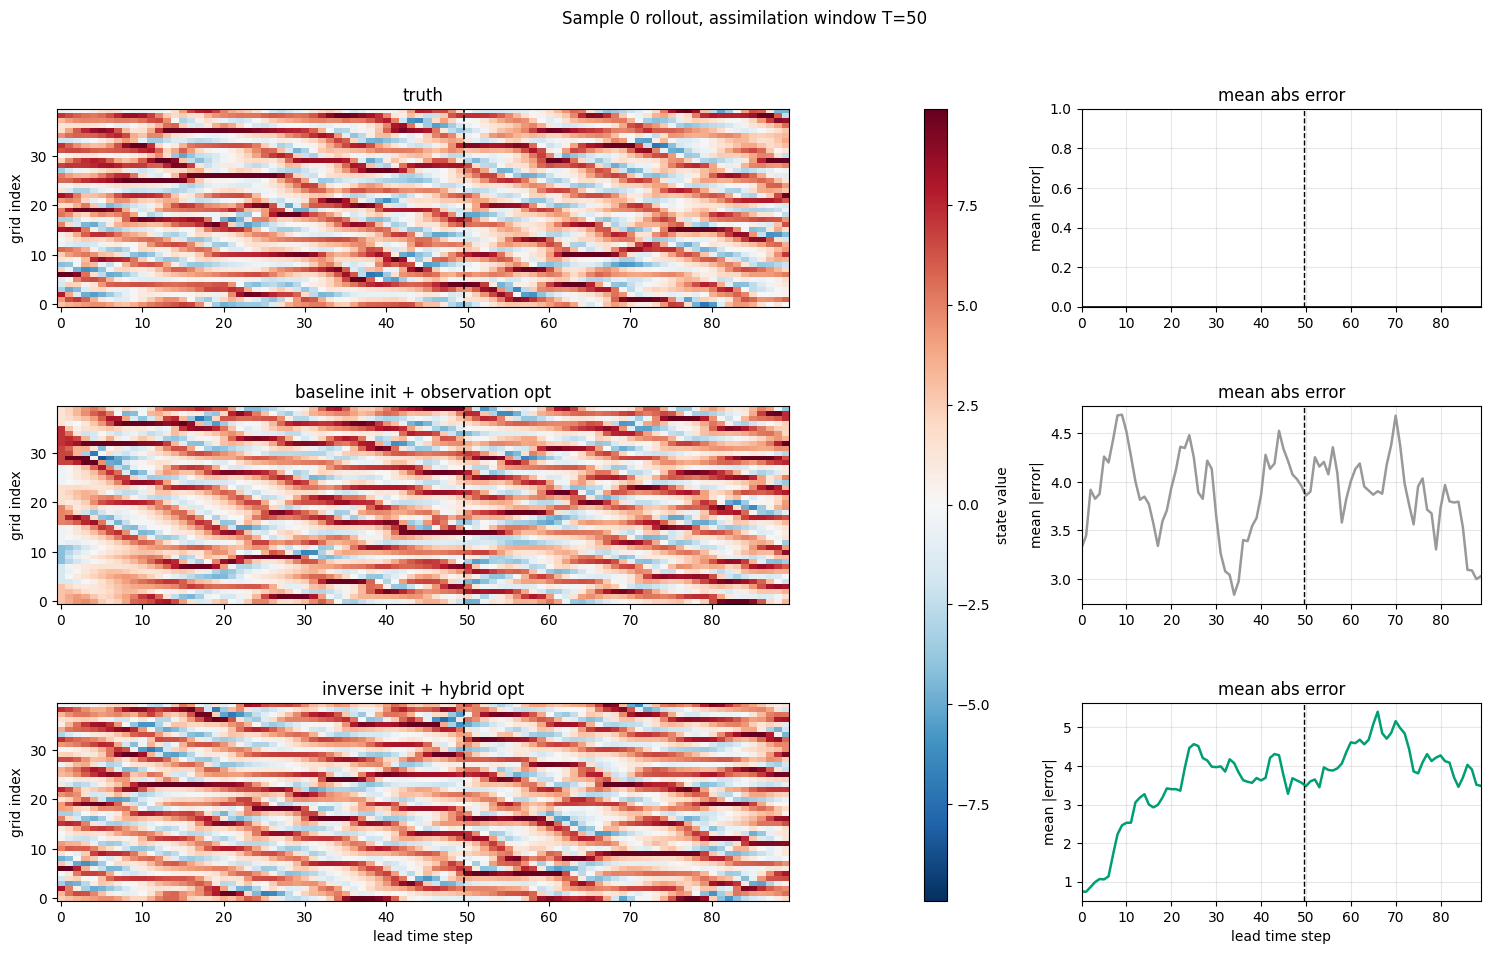

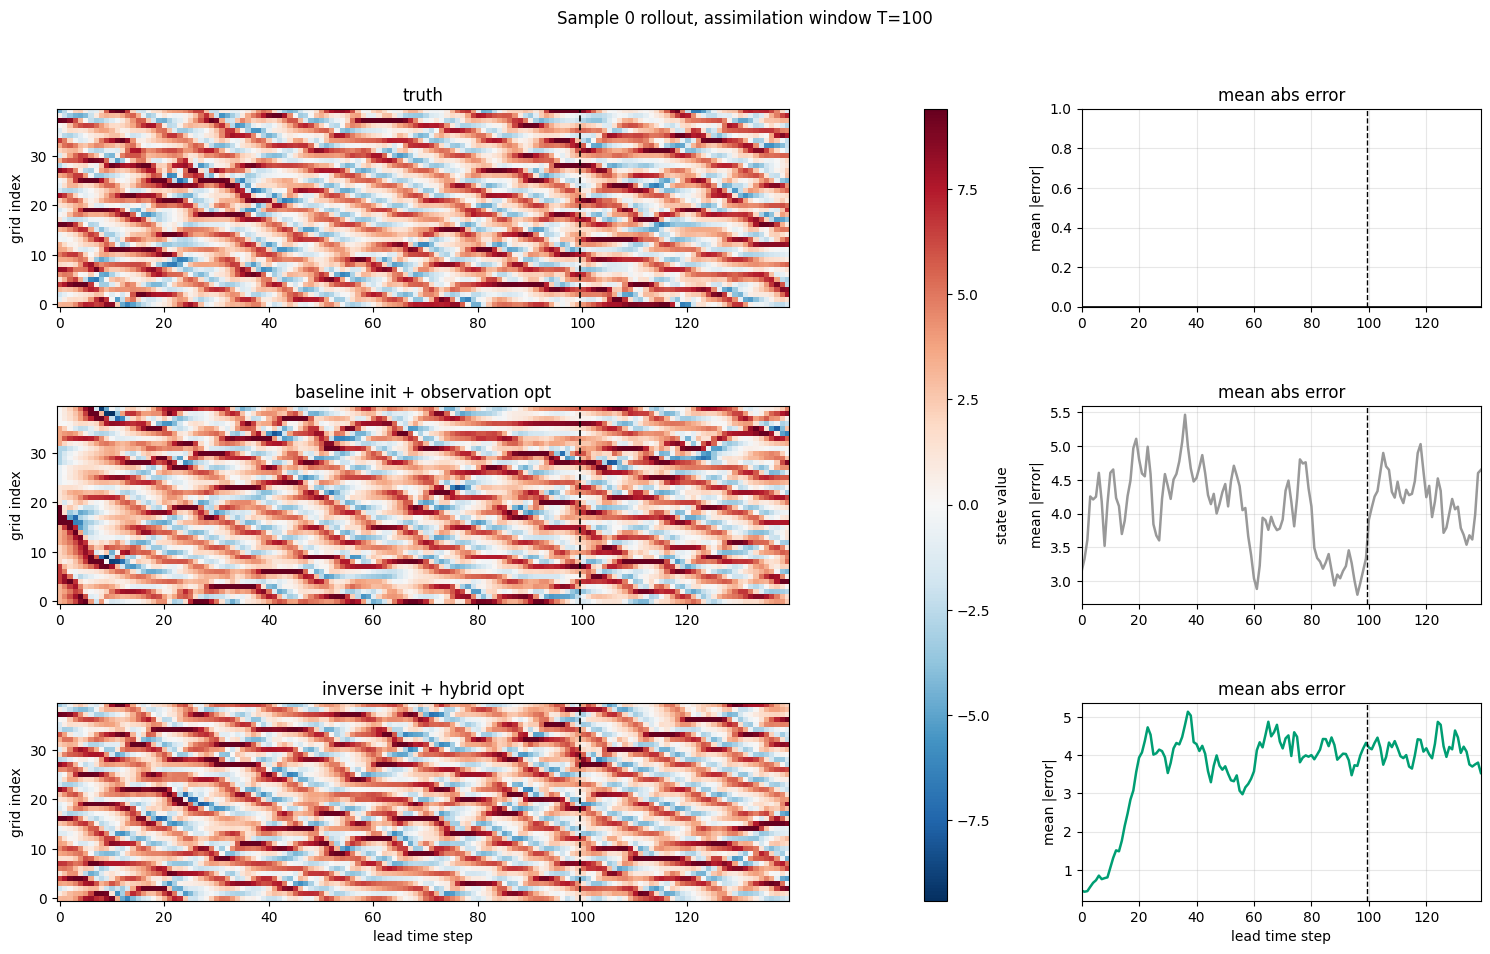

In [36]:
# Hovmoller-style state rollouts for selected windows and methods.
ROLLOUT_STATE_WINDOWS = [t for t in [1, 5, 20, 50, 100] if t in ASSIM_WINDOWS]
ROLLOUT_STATE_METHODS = [
    'baseline init + observation opt',
    'inverse init + hybrid opt',
]
ROLLOUT_SAMPLE_IDX = 0

for T_show in ROLLOUT_STATE_WINDOWS:
    truth = truth_by_window.get(T_show)
    if truth is None:
        print(f'Skipping T={T_show}: truth_by_window has no cached truth for this window.')
        continue

    X0_truth_batch = truth['X0'].to(device)
    if ROLLOUT_SAMPLE_IDX >= X0_truth_batch.shape[0]:
        print(f'Skipping T={T_show}: sample index {ROLLOUT_SAMPLE_IDX} is out of range.')
        continue

    T_total = T_show + T_FORECAST
    truth_traj = L96.integrate(X0_truth_batch[ROLLOUT_SAMPLE_IDX], T_total).detach().cpu().numpy()
    rows_by_method = {r['method']: r for r in sweep_results if r['window'] == T_show}

    panels = [('truth', truth_traj, None)]
    for method in ROLLOUT_STATE_METHODS:
        row = rows_by_method.get(method)
        if row is None:
            print(f'Skipping {method} for T={T_show}: no recovered state found.')
            continue
        x0_opt = row['x0_opt'][ROLLOUT_SAMPLE_IDX].to(device)
        pred_traj = L96.integrate(x0_opt, T_total).detach().cpu().numpy()
        err_t = np.abs(pred_traj - truth_traj).mean(axis=1)
        panels.append((method, pred_traj, err_t))

    vlim = np.nanpercentile(np.abs(truth_traj), 98)
    fig = plt.figure(figsize=(16, 3.3 * len(panels)), constrained_layout=False)
    gs = fig.add_gridspec(
        len(panels), 3,
        width_ratios=[4.4, 0.14, 2.4],
        wspace=0.35, hspace=0.50,
    )
    cax = fig.add_subplot(gs[:, 1])

    for i, (label, traj, err_t) in enumerate(panels):
        ax_img = fig.add_subplot(gs[i, 0])
        ax_err = fig.add_subplot(gs[i, 2])
        im = ax_img.imshow(
            traj.T, aspect='auto', cmap='RdBu_r', vmin=-vlim, vmax=vlim,
            origin='lower', interpolation='nearest',
        )
        ax_img.axvline(T_show - 0.5, color='k', lw=1.2, ls='--')
        ax_img.set_ylabel('grid index')
        ax_img.set_title(label)

        if err_t is None:
            ax_err.plot(np.zeros(T_total), color='k', lw=1.2)
            ax_err.set_ylim(0, 1)
        else:
            ax_err.plot(err_t, color=colors.get(label, '#333333'), lw=1.8)
        ax_err.axvline(T_show - 0.5, color='k', lw=1.0, ls='--')
        ax_err.set_xlim(0, T_total - 1)
        ax_err.set_title('mean abs error')
        ax_err.set_ylabel('mean |error|')
        ax_err.tick_params(axis='y', labelleft=True)
        ax_err.grid(alpha=0.3)

        if i == len(panels) - 1:
            ax_img.set_xlabel('lead time step')
            ax_err.set_xlabel('lead time step')

    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label('state value')
    fig.suptitle(f'Sample {ROLLOUT_SAMPLE_IDX} rollout, assimilation window T={T_show}', y=0.98)
    fig.subplots_adjust(top=0.88, left=0.07, right=0.96, bottom=0.08)
    plt.show()

### Closure histories for edge windows

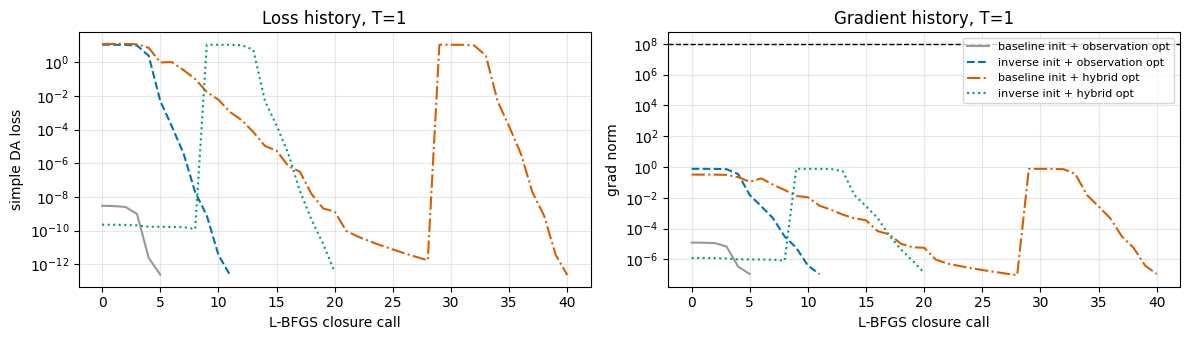

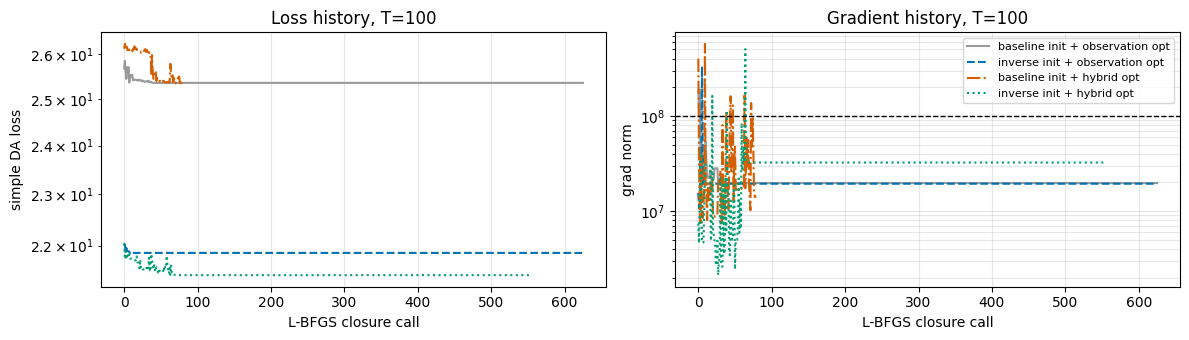

In [17]:
# Inspect loss and gradient histories for the shortest and longest windows.
for T_show in [ASSIM_WINDOWS[0], ASSIM_WINDOWS[-1]]:
    rows = [r for r in sweep_results if r['window'] == T_show]
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
    for row in rows:
        losses = combine_stage_history(row['stage_diags'], 'loss')
        grads = combine_stage_history(row['stage_diags'], 'grad_norm')
        if losses:
            axes[0].plot(losses, label=row['method'], color=colors[row['method']], linestyle=linestyles[row['method']])
        if grads:
            axes[1].plot(grads, label=row['method'], color=colors[row['method']], linestyle=linestyles[row['method']])
    axes[0].set_yscale('log')
    axes[0].set_xlabel('L-BFGS closure call')
    axes[0].set_ylabel('simple DA loss')
    axes[0].set_title(f'Loss history, T={T_show}')
    axes[0].grid(alpha=0.3)
    axes[1].set_yscale('log')
    axes[1].axhline(GRAD_EXPLODE_THRESHOLD, color='k', linestyle='--', linewidth=1)
    axes[1].set_xlabel('L-BFGS closure call')
    axes[1].set_ylabel('grad norm')
    axes[1].set_title(f'Gradient history, T={T_show}')
    axes[1].grid(alpha=0.3, which='both')
    axes[1].legend(fontsize=8)
    plt.tight_layout()
    plt.show()